# RMS Titanic Comprehensive Survival Analysis

### Pipeline
```
Raw CSV -> Inspect -> Clean & Validate -> Feature Engineering
        -> EDA Aggregations -> Visualisations -> Insights
```

---
## Imports & Config

In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

---
## Load & Inspect Raw Data

A full audit before touching anything: shape, dtypes, sample rows, unique values, and missing-value counts.

> **Key observation:** pandas reports zero nulls on load -- but the raw data uses `\N` as a sentinel string for missing values, which is invisible to the standard null check. Always inspect unique values for each column before trusting `.isnull()` counts.

In [95]:
df_titanic = pd.read_csv('titanic.csv')
df     = df_titanic.copy()

# Display
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.2500,\N,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,7.9250,\N,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35,0,0,373450,8.0500,\N,S


In [96]:
print(f'Shape: {df.shape[0]:,} rows  x  {df.shape[1]} columns')

Shape: 891 rows  x  12 columns


In [97]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    object 
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        891 non-null    object 
 11  Embarked     891 non-null    object 
dtypes: float64(1), int64(5), object(6)
memory usage: 83.7+ KB


In [98]:
# Before replacing sentinels -- this exposes the hidden missing values
for col in df.columns:
    print(f'{col:15s}: {df[col].unique()[:15].tolist()}')
    print()

PassengerId    : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]

Survived       : [0, 1]

Pclass         : [3, 1, 2]

Name           : ['Braund, Mr. Owen Harris', 'Cumings, Mrs. John Bradley (Florence Briggs Thayer)', 'Heikkinen, Miss. Laina', 'Futrelle, Mrs. Jacques Heath (Lily May Peel)', 'Allen, Mr. William Henry', 'Moran, Mr. James', 'McCarthy, Mr. Timothy J', 'Palsson, Master. Gosta Leonard', 'Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)', 'Nasser, Mrs. Nicholas (Adele Achem)', 'Sandstrom, Miss. Marguerite Rut', 'Bonnell, Miss. Elizabeth', 'Saundercock, Mr. William Henry', 'Andersson, Mr. Anders Johan', 'Vestrom, Miss. Hulda Amanda Adolfina']

Sex            : ['male', 'female']

Age            : ['22', '38', '26', '35', '\\N', '54', '2', '27', '14', '4', '58', '20', '39', '55', '31']

SibSp          : [1, 0, 3, 4, 2, 5, 8]

Parch          : [0, 1, 2, 5, 3, 4, 6]

Ticket         : ['A/5 21171', 'PC 17599', 'STON/O2. 3101282', '113803', '373450', '330877', '17463', '34990

In [99]:
# Apparent null count before sentinel replacement -- deceptively clean
print('Null counts BEFORE sentinel replacement:')
print(df.isnull().sum())

Null counts BEFORE sentinel replacement:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64


---
##  Data Cleaning & Validation

### Issues identified

| Column | Problem | Volume | Strategy |
|---|---|---|---|
| All columns | `'\N'` used as sentinel string for NULL | Widespread | Replace with `np.nan` |
| `Age` | Stored as `object` after sentinel removal | 19.87% missing | Cast to float; impute with **Pclass+Sex group median** |
| `Cabin` | 77.1% missing -- too sparse to impute | 687 / 891 rows | Drop column; create binary `Cabin Known` flag |
| `Embarked` | Only 2 missing (0.22%) | 2 rows | Fill with mode (Southampton) |
| `Fare` | Already `float64` but re-validate | 0 missing | Assert only |

### Design decisions

**Age -- why Pclass+Sex group median, not global median?**  
Age correlates strongly with both class (wealthier passengers tended to be older) and sex (different travel patterns). Using a global median would assign the same value to a 3rd-class male and a 1st-class female. Grouping by both dimensions gives a much more contextually accurate fill.

**Cabin -- why a binary flag instead of imputation?**  
With 77.1% of values missing, any imputation would be fabricating data for three-quarters of the column. Instead, the missingness itself is informative -- passengers with a known cabin were almost certainly in 1st or 2nd class. A binary `Cabin Known` flag preserves this signal without introducing false precision.

In [100]:
#Replace sentinel strings with NaN 
df.replace('\\N', np.nan, inplace=True)

print('Null counts AFTER sentinel replacement:')
print(df.isnull().sum())

Null counts AFTER sentinel replacement:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [101]:
# Fix numeric dtypes 
to_num = ['Age', 'Fare']
for col in to_num:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    print(f'{col} type :{df[col].dtype}')
    print()

Age type :float64

Fare type :float64



In [102]:
# Cabin: create binary flag then drop the raw column
# 77.1% missing -- imputation would fabricate data for 3 in 4 passengers.
# The missingness itself carries signal (known cabin = likely higher class).
df['Cabin Known'] = df['Cabin'].notna().astype(int)
df.drop(columns=['Cabin'], inplace=True)

print('Cabin Known distribution:')
print(df['Cabin Known'].value_counts())
print()
# Validate the signal -- cabin-known passengers should skew toward 1st class
print('Cabin Known vs Pclass:')
print(df.groupby('Cabin Known')['Pclass'].value_counts().unstack().fillna(0).astype(int))

Cabin Known distribution:
Cabin Known
0    687
1    204
Name: count, dtype: int64

Cabin Known vs Pclass:
Pclass         1    2    3
Cabin Known               
0             40  168  479
1            176   16   12


In [103]:
# Embarked: fill 2 missing rows with mode 
# Southampton accounts for 72.3% of departures -- mode is appropriate
# for a near-negligible 0.22% missingness rate.
embarked_mode = df['Embarked'].mode()[0]
n_missing     = df['Embarked'].isna().sum()
df['Embarked'] = df['Embarked'].fillna(embarked_mode)

print(f'Embarked: filled {n_missing} NaN -> mode "{embarked_mode}" (Southampton)')

Embarked: filled 2 NaN -> mode "S" (Southampton)


In [104]:
# Age: impute with Pclass + Sex group median 
# Rationale: both class and sex correlate with age on the Titanic.
# groupby().transform() broadcasts the group median back to individual rows.

print('Group medians used for Age imputation:')
print(df.groupby(['Pclass', 'Sex'])['Age'].median().to_frame('Median Age'))

age_group_median = df.groupby(['Pclass', 'Sex'])['Age'].transform('median')
n_age_missing    = df['Age'].isna().sum()
df['Age']        = df['Age'].fillna(age_group_median)

print(f'\nAge: filled {n_age_missing} NaN with Pclass+Sex group median')
print(f'Age range after imputation: {df["Age"].min():.1f} - {df["Age"].max():.1f}')

Group medians used for Age imputation:
               Median Age
Pclass Sex               
1      female        35.0
       male          40.0
2      female        28.0
       male          30.0
3      female        21.5
       male          25.0

Age: filled 177 NaN with Pclass+Sex group median
Age range after imputation: 0.4 - 80.0


In [105]:
# Final validation: assert no nulls in critical columns 
critical_cols = ['Survived','Pclass','Sex','Age','SibSp','Parch','Fare','Embarked']

remaining = df[critical_cols].isnull().sum()
print('Remaining nulls in critical columns:')
print(remaining)

assert remaining.sum() == 0, 'Nulls remain in critical columns -- review pipeline'
print('\nAll critical columns clean -- 0 missing values')

Remaining nulls in critical columns:
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

All critical columns clean -- 0 missing values


---
## Feature Engineering

We derive five features that unlock richer analysis:

| Feature | Derivation | Purpose |
|---|---|---|
| `Family Size` | `SibSp + Parch + 1` | Total people travelling together (incl. self) |
| `Is Alone` | `Family Size == 1` | Binary flag for solo travellers |
| `Age Band` | `pd.cut` on Age | Categorical age groups for survival analysis |
| `Fare Band` | `pd.cut` on Fare | Categorical fare tiers |
| `Title` | Regex extract from Name | Social status proxy -- Mr, Mrs, Miss, Master, Rare |

In [106]:
# Family size and solo travel flag
df['Family Size'] = df['SibSp'] + df['Parch'] + 1
df['Is Alone']    = (df['Family Size'] == 1).astype(int)

print('Family Size distribution:')
print(df['Family Size'].value_counts().sort_index())
print(f'\nSolo travellers: {df["Is Alone"].sum()} ({df["Is Alone"].mean():.1%})')

Family Size distribution:
Family Size
1     537
2     161
3     102
4      29
5      15
6      22
7      12
8       6
11      7
Name: count, dtype: int64

Solo travellers: 537 (60.3%)


In [107]:
# Age bands and fare bands using pd.cut
age_bins   = [0, 12, 18, 35, 60, 100]
age_labels = ['Child', 'Teen', 'Young Adult', 'Adult', 'Senior']
df['Age Band'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels)

fare_bins   = [0, 7.91, 14.45, 31.0, 600]
fare_labels = ['Low', 'Medium', 'High', 'Very High']
df['Fare Band'] = pd.cut(df['Fare'], bins=fare_bins, labels=fare_labels)

print('Age Band counts:')
print(df['Age Band'].value_counts())
print()
print('Fare Band counts:')
print(df['Fare Band'].value_counts())

Age Band counts:
Age Band
Young Adult    514
Adult          216
Teen            70
Child           69
Senior          22
Name: count, dtype: int64

Fare Band counts:
Fare Band
High         229
Very High    222
Medium       217
Low          208
Name: count, dtype: int64


In [108]:
# Title extraction from Name using regex
# The pattern captures the title between ', ' and '.' in each name string
df['Title'] = df['Name'].str.extract(r',\s*([^\.]+)\.', expand=False).str.strip()

print('Raw title counts:')
print(df['Title'].value_counts())

# Consolidate titles with fewer than 10 passengers into 'Rare'
rare_titles = df['Title'].value_counts()
rare_titles = rare_titles[rare_titles < 10].index.tolist()
df['Title'] = df['Title'].replace(rare_titles, 'Rare')

print('\nConsolidated title counts:')
print(df['Title'].value_counts())

Raw title counts:
Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Col               2
Mlle              2
Major             2
Ms                1
Mme               1
Don               1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64

Consolidated title counts:
Title
Mr        517
Miss      182
Mrs       125
Master     40
Rare       27
Name: count, dtype: int64


In [109]:
# Class label for readable plot axes
df['Class Label'] = df['Pclass'].map({1: '1st', 2: '2nd', 3: '3rd'})

print('Feature engineering complete. New columns added:')
print([c for c in df.columns if c not in df_titanic.columns])

Feature engineering complete. New columns added:
['Cabin Known', 'Family Size', 'Is Alone', 'Age Band', 'Fare Band', 'Title', 'Class Label']


In [110]:
# save the cleaned and feature-engineered dataset for future use
df.to_csv('titanic_cleaned.csv', index=False)

---
## Exploratory Data Analysis

All aggregations computed here and printed for inspection before plotting.

In [111]:
# Core survival aggregations
overall_rate   = df['Survived'].mean()
surv_sex       = df.groupby('Sex')['Survived'].mean().sort_values(ascending=False)
surv_class     = df.groupby('Class Label')['Survived'].mean().reindex(['1st','2nd','3rd'])
surv_age_band  = df.groupby('Age Band', observed=True)['Survived'].mean()
surv_sex_class = df.groupby(['Pclass','Sex'])['Survived'].mean().unstack()
surv_title     = df.groupby('Title')['Survived'].mean().sort_values(ascending=False)
surv_alone     = df.groupby('Is Alone')['Survived'].mean()
surv_family    = df.groupby('Family Size')['Survived'].mean()
surv_embarked  = df.groupby('Embarked')['Survived'].mean().sort_values(ascending=False)
surv_fare_band = df.groupby('Fare Band', observed=True)['Survived'].mean()

print('All aggregations ready')

All aggregations ready


In [112]:
print(f'Overall survival rate: {overall_rate:.1%}')
print(f'Survived: {df["Survived"].sum()}  |  Perished: {(df["Survived"]==0).sum()}')
print()
print('Survival rate by Sex:')
print(surv_sex.apply(lambda x: f'{x:.1%}').to_frame('Survival Rate'))
print()
print('Survival rate by Class:')
print(surv_class.apply(lambda x: f'{x:.1%}').to_frame('Survival Rate'))

Overall survival rate: 38.4%
Survived: 342  |  Perished: 549

Survival rate by Sex:
       Survival Rate
Sex                 
female         74.2%
male           18.9%

Survival rate by Class:
            Survival Rate
Class Label              
1st                 63.0%
2nd                 47.3%
3rd                 24.2%


In [113]:
print('Survival rate by Age Band:')
print(surv_age_band.apply(lambda x: f'{x:.1%}').to_frame('Survival Rate'))
print()
print('Survival rate by Title:')
print(surv_title.apply(lambda x: f'{x:.1%}').to_frame('Survival Rate'))

Survival rate by Age Band:
            Survival Rate
Age Band                 
Child               58.0%
Teen                42.9%
Young Adult         35.8%
Adult               38.4%
Senior              22.7%

Survival rate by Title:
       Survival Rate
Title               
Mrs            79.2%
Miss           69.8%
Master         57.5%
Rare           44.4%
Mr             15.7%


In [114]:
print('Survival rate by Family Size:')
print(surv_family.apply(lambda x: f'{x:.1%}').to_frame('Survival Rate'))
print()
print('Travelling Alone vs With Family:')
print(surv_alone.rename({0: 'With Family', 1: 'Alone'})
                .apply(lambda x: f'{x:.1%}').to_frame('Survival Rate'))

Survival rate by Family Size:
            Survival Rate
Family Size              
1                   30.4%
2                   55.3%
3                   57.8%
4                   72.4%
5                   20.0%
6                   13.6%
7                   33.3%
8                    0.0%
11                   0.0%

Travelling Alone vs With Family:
            Survival Rate
Is Alone                 
With Family         50.6%
Alone               30.4%


In [115]:
# Sex x Class cross-tab -- the most powerful single combination
print('Survival rate by Sex x Class (%):')
print((surv_sex_class * 100).round(1))
print()
print('Summary statistics:')
df[['Age', 'Fare', 'Family Size']].describe()

Survival rate by Sex x Class (%):
Sex     female  male
Pclass              
1         96.8  36.9
2         92.1  15.7
3         50.0  13.5

Summary statistics:


,Age,Fare,Family Size
count,891.000000,891.000000,891.000000
mean,29.112424,32.204208,1.904602
std,13.304424,49.693429,1.613459
min,0.420000,0.000000,1.000000
25%,21.500000,7.910400,1.000000
50%,26.000000,14.454200,1.000000
75%,36.000000,31.000000,2.000000
max,80.000000,512.329200,11.000000


---
## Visualisations

Ten purpose-built charts, each in its own cell. Green/teal = higher survival, red = lower survival throughout.

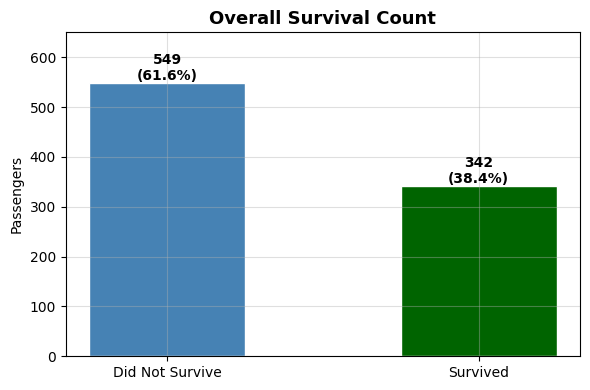

In [116]:
# Fig 1: Overall Survival Count -
fig, ax = plt.subplots(figsize=(6, 4))
color = ['steelblue', 'darkgreen']
surv_counts = df['Survived'].value_counts().sort_index()
bars = ax.bar(['Did Not Survive', 'Survived'], surv_counts.values,
              color=color, edgecolor='white', width=0.5)

for bar, val in zip(bars, surv_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
            f'{val}\n({val/len(df):.1%})',
            ha='center', fontsize=10, fontweight='bold')

ax.set_title('Overall Survival Count', fontweight='bold', fontsize=13)
ax.set_ylabel('Passengers')
ax.set_ylim(0, 650)
plt.tight_layout()
plt.grid(alpha=0.4)
plt.show()

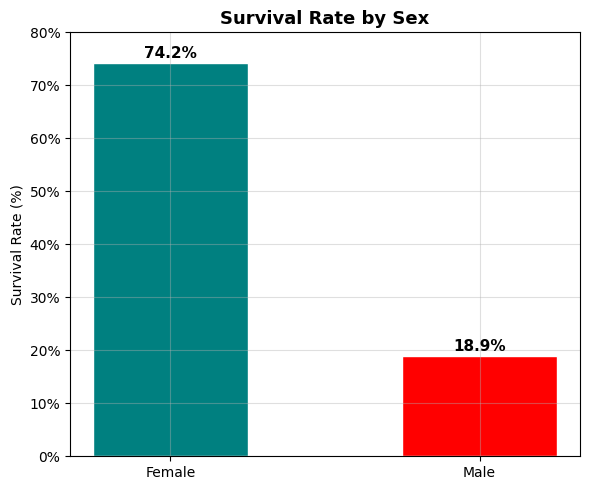

In [117]:
# Fig 2: Survival Rate by Sex 
fig, ax = plt.subplots(figsize=(6, 5))

color = ['teal' if val * 100 > 50 else 'red' for val in surv_sex.values]
bars = ax.bar(surv_sex.index.str.capitalize(), surv_sex.values * 100,
              color=color, edgecolor='white', width=0.5)

for bar, val in zip(bars, surv_sex.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f'{val:.1%}', ha='center', fontsize=11, fontweight='bold')

ax.set_title('Survival Rate by Sex', fontweight='bold', fontsize=13)
ax.set_ylabel('Survival Rate (%)')
ax.set_ylim(0, 80)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
plt.tight_layout()
plt.grid(alpha=0.4)
plt.show()

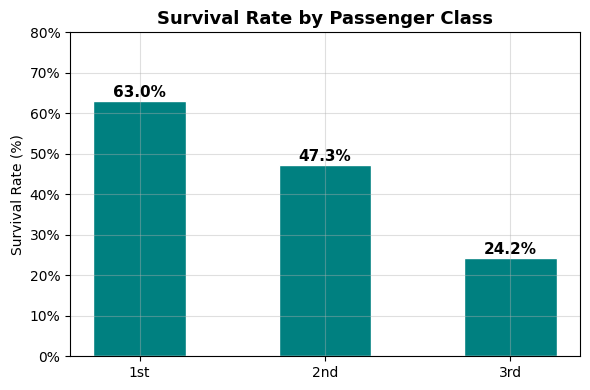

In [118]:
# Fig 3: Survival Rate by Passenger Class 
fig, ax = plt.subplots(figsize=(6, 4))

for bar, val, color in zip(ax.bar(surv_class.index, surv_class.values * 100,
                                   color='teal', edgecolor='white', width=0.5),
                            surv_class.values, 'teal'):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f'{val:.1%}', ha='center', fontsize=11, fontweight='bold')

ax.set_title('Survival Rate by Passenger Class', fontweight='bold', fontsize=13)
ax.set_ylabel('Survival Rate (%)')
ax.set_ylim(0, 80)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
plt.tight_layout()
plt.grid(alpha=0.4)
plt.show()

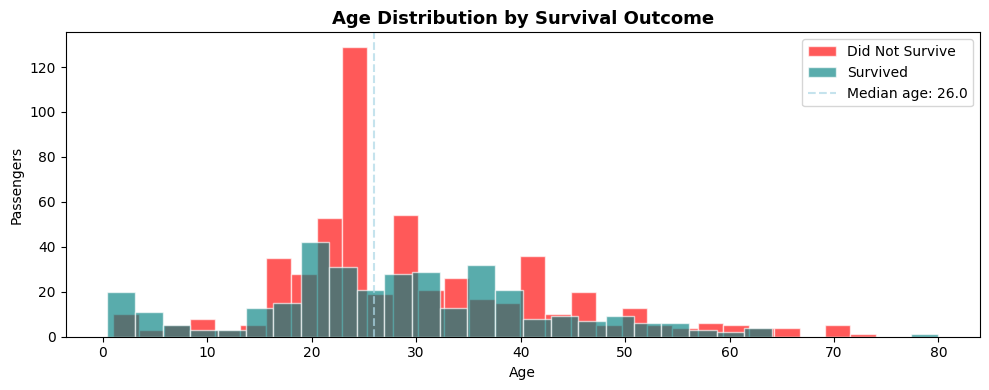

In [119]:
# Fig 4: Age Distribution by Survival Outcome 
fig, ax = plt.subplots(figsize=(10, 4))

for survived, label, color in [(0, 'Did Not Survive', 'red'), (1, 'Survived', 'teal')]:
    subset = df[df['Survived'] == survived]['Age']
    ax.hist(subset, bins=30, alpha=0.65, label=label, color=color, edgecolor='white')

ax.axvline(df['Age'].median(), color='lightblue', linestyle='--',
           linewidth=1.5, alpha=0.7, label=f'Median age: {df["Age"].median():.1f}')
ax.set_title('Age Distribution by Survival Outcome', fontweight='bold', fontsize=13)
ax.set_xlabel('Age')
ax.set_ylabel('Passengers')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

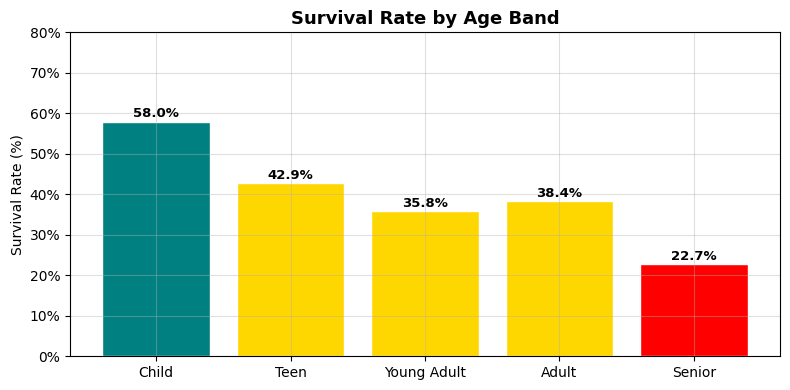

In [120]:
# Fig 5: Survival Rate by Age Band 
fig, ax = plt.subplots(figsize=(8, 4))

age_band_colors = [
    'teal' if v == surv_age_band.max() else
    'red'  if v == surv_age_band.min() else 'gold'
    for v in surv_age_band.values
]
bars = ax.bar(surv_age_band.index.astype(str), surv_age_band.values * 100,
              color=age_band_colors, edgecolor='white')

for bar, val in zip(bars, surv_age_band.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f'{val:.1%}', ha='center', fontsize=9.5, fontweight='bold')

ax.set_title('Survival Rate by Age Band', fontweight='bold', fontsize=13)
ax.set_ylabel('Survival Rate (%)')
ax.set_ylim(0, 80)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
plt.tight_layout()
plt.grid(alpha=0.4)
plt.show()

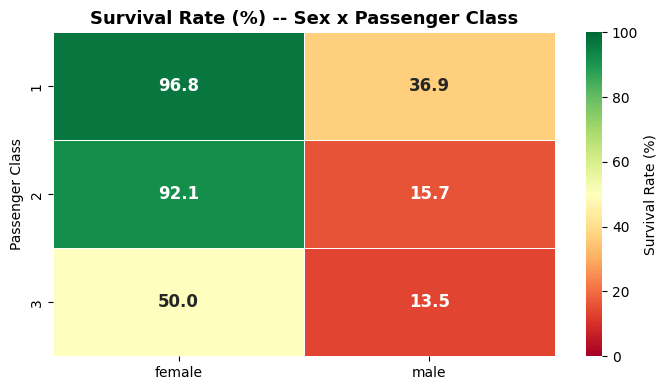

In [121]:
# Fig 6: Sex x Class Survival Heatmap 
# This is the single most revealing combination in the dataset.
# The 'women and children first' policy shows up starkly here.
fig, ax = plt.subplots(figsize=(7, 4))

sns.heatmap(
    surv_sex_class * 100, ax=ax,
    cmap='RdYlGn', annot=True, fmt='.1f',
    linewidths=0.5, vmin=0, vmax=100,
    cbar_kws={'label': 'Survival Rate (%)'},
    annot_kws={'size': 12, 'fontweight': 'bold'},
)
ax.set_title('Survival Rate (%) -- Sex x Passenger Class', fontweight='bold', fontsize=13)
ax.set_ylabel('Passenger Class')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

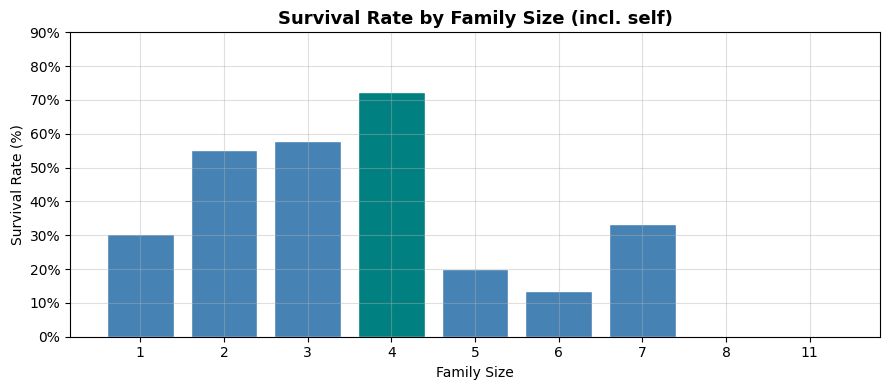

In [122]:
# -- Chart 7: Survival Rate by Family Size -------------------------
fig, ax = plt.subplots(figsize=(9, 4))

fam_colors = ['teal' if v == surv_family.max() else 'steelblue' for v in surv_family.values]
ax.bar(surv_family.index.astype(str), surv_family.values * 100,
       color=fam_colors, edgecolor='white')

ax.set_title('Survival Rate by Family Size (incl. self)', fontweight='bold', fontsize=13)
ax.set_xlabel('Family Size')
ax.set_ylabel('Survival Rate (%)')
ax.set_ylim(0, 90)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
plt.tight_layout()
plt.grid(alpha=0.4)
plt.show()

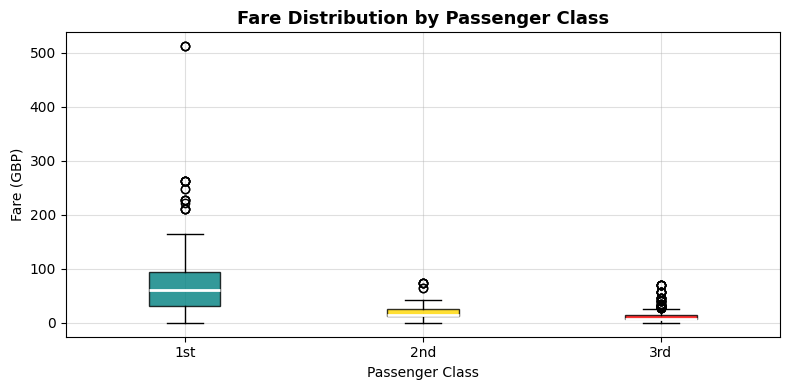

In [123]:
# Fig 8: Fare Distribution by Passenger Class (Boxplot) 
fig, ax = plt.subplots(figsize=(8, 4))

class_order = ['1st', '2nd', '3rd']
class_data  = [df[df['Class Label'] == c]['Fare'].dropna() for c in class_order]

bp = ax.boxplot(class_data, labels=class_order, patch_artist=True,
                medianprops=dict(color='white', linewidth=2))

for patch, color in zip(bp['boxes'], ['teal', 'gold', 'red']):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

ax.set_title('Fare Distribution by Passenger Class', fontweight='bold', fontsize=13)
ax.set_ylabel('Fare (GBP)')
ax.set_xlabel('Passenger Class')
plt.tight_layout()
plt.grid(alpha=0.4)
plt.show()

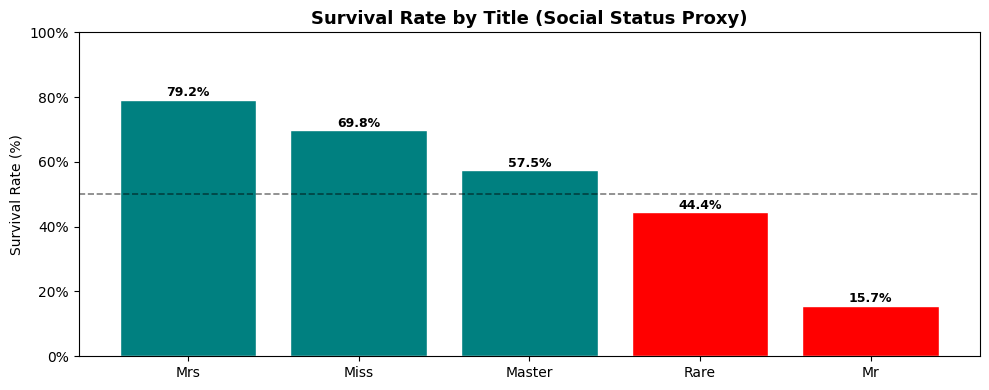

In [124]:
# Fig 9: Survival Rate by Title (Social Status Proxy) 
fig, ax = plt.subplots(figsize=(10, 4))

title_colors = ['teal' if v >= 0.5 else 'red' for v in surv_title.values]
bars = ax.bar(surv_title.index, surv_title.values * 100,
              color=title_colors, edgecolor='white')

for bar, val in zip(bars, surv_title.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f'{val:.1%}', ha='center', fontsize=9, fontweight='bold')

ax.axhline(50, color='black', linestyle='--', linewidth=1.2, alpha=0.5)
ax.set_title('Survival Rate by Title (Social Status Proxy)', fontweight='bold', fontsize=13)
ax.set_ylabel('Survival Rate (%)')
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
plt.tight_layout()
plt.show()

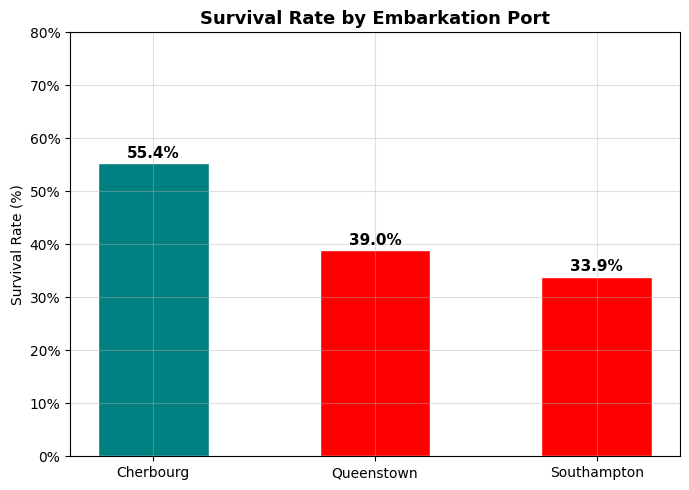

In [125]:
# Fig 10: Survival Rate by Embarkation Port 
port_map    = {'S': 'Southampton', 'C': 'Cherbourg', 'Q': 'Queenstown'}
port_labels = [port_map.get(e, e) for e in surv_embarked.index]
port_colors = ['teal' if v == surv_embarked.max() else 'red' for v in surv_embarked.values]

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(port_labels, surv_embarked.values * 100,
              color=port_colors, edgecolor='white', width=0.5)

for bar, val in zip(bars, surv_embarked.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f'{val:.1%}', ha='center', fontsize=11, fontweight='bold')

ax.set_title('Survival Rate by Embarkation Port', fontweight='bold', fontsize=13)
ax.set_ylabel('Survival Rate (%)')
ax.set_ylim(0, 80)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
plt.tight_layout()
plt.grid(alpha=0.4)
plt.show()

---
## Stage 6 -- Key Metrics Summary

In [126]:
metrics = {
    'Total Passengers':          f'{len(df):,}',
    'Survived':                  f'{df["Survived"].sum():,}  ({overall_rate:.1%})',
    'Perished':                  f'{(df["Survived"]==0).sum():,}  ({1-overall_rate:.1%})',
    'Female Survival Rate':      f'{surv_sex["female"]:.1%}',
    'Male Survival Rate':        f'{surv_sex["male"]:.1%}',
    '1st Class Survival Rate':   f'{surv_class["1st"]:.1%}',
    '2nd Class Survival Rate':   f'{surv_class["2nd"]:.1%}',
    '3rd Class Survival Rate':   f'{surv_class["3rd"]:.1%}',
    'Best Age Band':             f'{surv_age_band.idxmax()}  ({surv_age_band.max():.1%})',
    'Solo Traveller Rate':       f'{df["Is Alone"].mean():.1%}',
    'Avg Fare':                  f'GBP {df["Fare"].mean():.2f}',
    'Median Age (post-impute)':  f'{df["Age"].median():.1f} years',
}

print('=' * 56)
print('      RMS TITANIC -- KEY SURVIVAL METRICS')
print('=' * 56)
for label, value in metrics.items():
    print(f'  {label:<32s}  {value}')
print('=' * 56)

      RMS TITANIC -- KEY SURVIVAL METRICS
  Total Passengers                  891
  Survived                          342  (38.4%)
  Perished                          549  (61.6%)
  Female Survival Rate              74.2%
  Male Survival Rate                18.9%
  1st Class Survival Rate           63.0%
  2nd Class Survival Rate           47.3%
  3rd Class Survival Rate           24.2%
  Best Age Band                     Child  (58.0%)
  Solo Traveller Rate               60.3%
  Avg Fare                          GBP 32.20
  Median Age (post-impute)          26.0 years


---
## Stage 7 -- Key Insights & Findings

| # | Finding | Insight |
|---|---|---|
| 1 | **Sex is the strongest survival predictor** (74.2% female vs 18.9% male) | 'Women and children first' protocol was enforced with striking consistency |
| 2 | **Class amplifies the sex effect** -- 1st class female: 96.8%, 3rd class male: 13.5% | Wealth determined proximity to lifeboats and crew attention |
| 3 | **Children had the highest survival rate** (58.0%) | Age-based priority was applied alongside sex-based priority |
| 4 | **Solo travellers survived less** (30.4%) than those with small families | Small groups (2-4) may have worked together to secure lifeboat spots |
| 5 | **Large families (5+) had very low survival** | Difficulty coordinating evacuation for large groups in the chaos |
| 6 | **Cherbourg passengers survived at a higher rate** than Southampton | Cherbourg boarders skewed heavily toward 1st class -- a confounding class effect |
| 7 | **Mrs / Miss titles survived at 79%+ vs Mr at 16%** | Title analysis confirms the sex and class effects through a social-status lens |
| 8 | **77.1% of Cabin data was missing** | This was converted to a binary `Cabin Known` flag -- its correlation with 1st class is itself a survival signal |

---
*Analysis produced with `pandas`, `numpy`, `matplotlib` & `seaborn`.*